# Customer Churn Prediction & LTV Engine

## Baseline Analytics Report — Day 1

### Prepared by: Akshay

This notebook contains the baseline customer metrics and initial
visual analysis for the Customer Churn Prediction & LTV Engine project.

### Objectives
- Calculate basic customer metrics
- Calculate customer churn percentage
- Understand basic customer characteristics
- Suggest charts for the final dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("WA_Fn-UseC_-Telco-Customer-Churn (1).csv.xlsx")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df[["tenure", "MonthlyCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [10]:
# Baseline Customer KPIs

total_customers = df.shape[0]
churned_customers = (df["Churn"] == "Yes").sum()
churn_rate = (churned_customers / total_customers) * 100
average_tenure = df["tenure"].mean()
average_monthly_charges = df["MonthlyCharges"].mean()

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", round(churn_rate, 2), "%")
print("Average Tenure:", round(average_tenure, 2), "months")
print("Average Monthly Charges:", round(average_monthly_charges, 2))

Total Customers: 7043
Churned Customers: 1869
Churn Rate: 26.54 %
Average Tenure: 32.37 months
Average Monthly Charges: 64.76


## 1. Baseline Customer KPIs

The following metrics provide an initial overview of the customer
base and the current churn situation.

In [15]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Churn Rate (%)",
        "Average Tenure (Months)",
        "Average Monthly Charges"
    ],
    "Value": [
        total_customers,
        churned_customers,
        round(churn_rate, 2),
        round(average_tenure, 2),
        round(average_monthly_charges, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Churn Rate (%),26.54
3,Average Tenure (Months),32.37
4,Average Monthly Charges,64.76


### Key Findings

- The dataset contains 7,043 customers.
- 1,869 customers have churned.
- The overall churn rate is 26.54%.
- Average customer tenure is 32.37 months.
- Average monthly charge is 64.76.

## 2. Customer Churn Distribution

This chart compares customers who stayed with the company against
customers who churned.

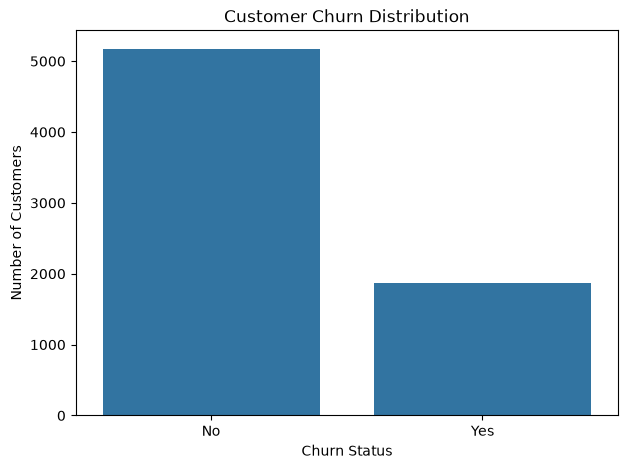

In [11]:
# Churn Distribution

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=churn_counts.index, y=churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

### Finding

The dataset contains 5,174 customers who did not churn and
1,869 customers who churned. The overall churn rate is 26.54%.

## 3. Churn Rate by Contract Type

This analysis compares the percentage of customers who churn
across different contract types.

In [12]:
# Churn by Contract Type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Finding

Month-to-month contract customers have the highest churn rate,
while two-year contract customers have the lowest churn rate.

This indicates that contract type is strongly associated with
customer churn in this dataset.

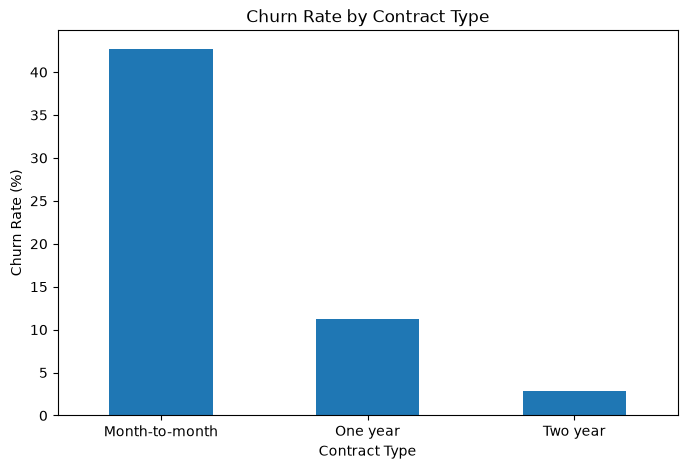

In [13]:
# Visualize churn rate by contract type

contract_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 4. Dashboard Recommendations

Based on the baseline analysis, the following elements are recommended
for the final customer churn dashboard.

### KPI Cards

- Total Customers
- Churned Customers
- Churn Rate
- Average Tenure
- Average Monthly Charges

### Recommended Charts

1. Customer Churn Distribution
2. Churn Rate by Contract Type
3. Churn Rate by Internet Service
4. Churn Rate by Payment Method
5. Churn Rate by Tenure

### Dashboard Purpose

The dashboard should provide a simple overview of the customer base,
highlight the current churn situation, and help stakeholders identify
customer segments that may require further investigation.

The final dashboard design and additional charts should be confirmed
with the team before implementation.

## 5. Conclusion

The baseline analysis provides an initial understanding of the
customer population and churn situation.

The dataset contains 7,043 customers, of which 1,869 have churned,
resulting in an overall churn rate of 26.54%.

The average customer tenure is 32.37 months and the average monthly
charge is 64.76.

The initial visual analysis also shows a clear difference in churn
rates across contract types, with month-to-month customers showing
the highest churn rate.

These results provide the baseline information required for the
next stages of the Customer Churn Prediction & LTV Engine project.